# Victor MArtinez EDA

## Research Question

Does age group or sex affect how long the cats stay in the system?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Load the dataset
df = pd.read_csv("../data/raw/cats_data_filtered.csv")

In [5]:
# Convert date columns to datetime format
df['adoptedDate'] = pd.to_datetime(df['adoptedDate'], errors='coerce')

df['availableDate'] = pd.to_datetime(df['availableDate'], errors='coerce')

In [6]:
# Create a new column showing how long cats stayed in the system
df['length_of_stay'] = (df['adoptedDate'] - df['availableDate']).dt.days

In [7]:
# Remove rows with missing important values
df = df.dropna(subset=['length_of_stay', 'sex', 'ageGroup'])

In [8]:
# Check dataset shape
df.shape

(4269, 26)

In [9]:
# View column names
df.columns

Index(['id', 'sex', 'sizeCurrent', 'sizeGroup', 'ageGroup', 'ageString',
       'breedString', 'colorDetails', 'vocalLevel', 'sheddingLevel',
       'energyLevel', 'exerciseNeeds', 'isSpecialNeeds',
       'isCurrentVaccinations', 'isDeclawed', 'isHousetrained', 'isKidsOk',
       'adultSexesOk', 'obedienceTraining', 'ownerExperience',
       'newPeopleReaction', 'pictureCount', 'videoCount', 'adoptedDate',
       'availableDate', 'length_of_stay'],
      dtype='str')

In [10]:
# Check missing values
df.isnull().sum()

id                          0
sex                         0
sizeCurrent              2596
sizeGroup                1298
ageGroup                    0
ageString                 315
breedString                 0
colorDetails             3044
vocalLevel               3639
sheddingLevel            3436
energyLevel              2820
exerciseNeeds            3131
isSpecialNeeds           1036
isCurrentVaccinations    1414
isDeclawed               1309
isHousetrained           1127
isKidsOk                 2092
adultSexesOk             2602
obedienceTraining        3904
ownerExperience          4072
newPeopleReaction        2481
pictureCount                0
videoCount                  0
adoptedDate                 0
availableDate               0
length_of_stay              0
dtype: int64

In [11]:
# Summary statistics for length of stay

df['length_of_stay'].describe()

count    4269.000000
mean       68.748653
std       216.163728
min     -3590.000000
25%         8.000000
50%        25.000000
75%        62.000000
max      3481.000000
Name: length_of_stay, dtype: float64

In [12]:
# Average length of stay by sex
df.groupby('sex')['length_of_stay'].mean()

sex
Female    76.186588
Male      60.898893
Name: length_of_stay, dtype: float64

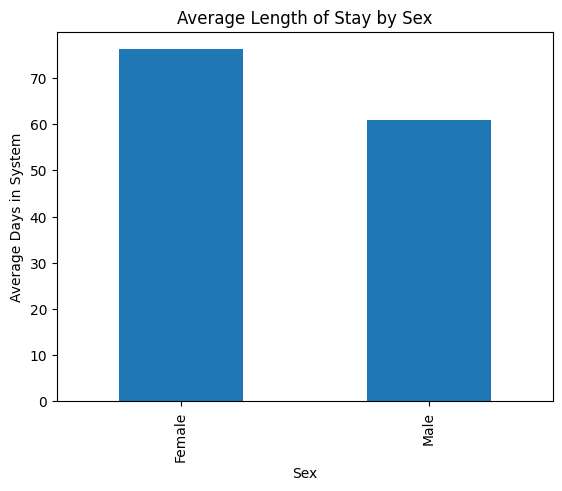

In [13]:
#Bar chart for average stay by sex
df.groupby('sex')['length_of_stay'].mean().plot(kind='bar')

plt.title('Average Length of Stay by Sex')
plt.xlabel('Sex')
plt.ylabel('Average Days in System')

plt.show()

In [14]:
# Average length of stay by age group
df.groupby('ageGroup')['length_of_stay'].mean()

ageGroup
Adult     144.209363
Baby       36.900298
Senior    389.018519
Young      68.224750
Name: length_of_stay, dtype: float64

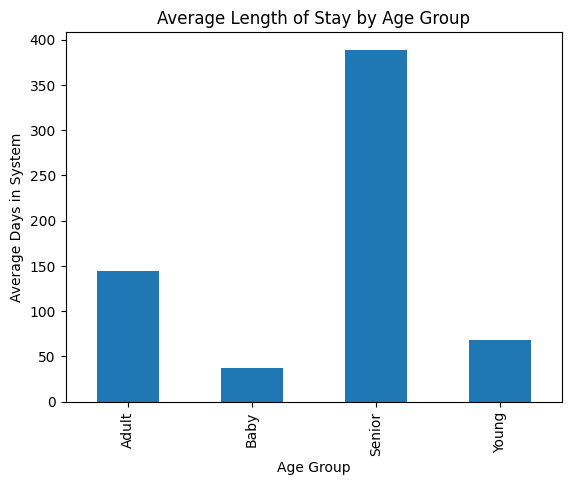

In [15]:
#Bar chart for average stay by age group
df.groupby('ageGroup')['length_of_stay'].mean().plot(kind='bar')

plt.title('Average Length of Stay by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Days in System')

plt.show()

## Findings

- Senior cats stayed in the system the longest on average.
- Baby cats had the shortest average stay.
- Adult cats also stayed longer than younger cats.
- Female cats stayed slightly longer than the male cats.
- Age group had a much stronger effect on adoption time than sex.

## Conclusion

The age group plays an important role in how long cats remain in the system before adoption.

Senior Cats had the highest average length of stay, while baby cats were adopted the fastest. Sex appeared to have a similar impact, though female cats stayed slightly longer on average than male cats.

These findings are hopefully able to help shelters better understand adoption trends and improve strategies for helping older cats get adopted more quickly.